# Did the Regional Price Promotion Actually Pay Off?
### A Synthetic Control project for pricing & promotions analytics — built from *Causal Inference in Python*, Ch. 9

**The business question**

A retail chain runs a **limited-time price promotion** (e.g. "15% off") in a handful of states to test whether it lifts revenue enough to justify a national rollout. Because the promotion was launched in only **4 states out of 25**, and because pricing/marketing teams never randomize *which* states get picked (they pick states that are underperforming, or that are strategically important, or where the sales team lobbied hardest), this is a textbook **selection-on-unobservables** problem: you cannot just compare promoted vs. non-promoted states and call the difference "the effect of the promotion."

This notebook extends the previous synthetic-control project with two capabilities the book covers but we didn't use last time, both very relevant to a pricing/promotions setting:

1. **Synthetic Control *with covariates*** — besides each state's own pre-period revenue, we also have a **regional unemployment index** and a **competitor price index**, both plausibly predictive of revenue trends. The book's chapter shows how to fold these into the same convex-optimization objective by learning a scaling weight `v` for each block of predictors.
2. **In-space placebo tests** — a standard robustness check *not* covered in the previous project: re-run synthetic control pretending each *untreated* state was "treated," and compare the promoted states' effect size to the distribution of these placebo effects. If the real effect isn't much bigger than what you'd get by picking a random untreated state, you shouldn't trust it.

We'll still build **canonical SC**, **debiased/inference SC**, and **Synthetic DID (SDID)** exactly as before, then finish with a business-facing recommendation: *is the promotion worth rolling out nationally?*

> As before, we simulate the data ourselves with a **known, injected effect**, so we can check every estimator against ground truth at the end.


## 1. Setup

In [1]:
# %pip install pandas numpy scikit-learn cvxpy scipy matplotlib statsmodels toolz -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import cvxpy as cp
from scipy.optimize import minimize
from scipy.stats import t as t_dist
import statsmodels.formula.api as smf

rng = np.random.default_rng(7)
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.precision", 4)


## 2. Simulate a state-level pricing/promotion panel

We simulate **25 U.S. states**, of which **4 receive the promotion** on the same date. Daily `revenue_index` (normalized so states of different sizes are comparable — same trick the book uses for `app_download_pct`) is driven by:

- a **shared macro trend** (overall retail demand seasonality that hits every state),
- each state's **own loading** on that trend (bigger/more cyclical states move more with the macro trend),
- a **regional unemployment index** (higher unemployment → lower discretionary spend → lower revenue) — this will be our first covariate,
- a **competitor price index** (when competitors cut prices, our revenue softens) — our second covariate,
- idiosyncratic weekly seasonality and noise.

We inject a **true promotion effect**: revenue in promoted states jumps immediately when the discount launches, holds roughly steady while the promotion runs, then reverts once it ends — a realistic "promotion window" shape (as opposed to the marketing-campaign notebook's slow ramp-and-decay).


In [2]:
N_CONTROL = 21
N_TREATED = 4
N_DAYS = 130
PROMO_START_IDX = 70   # promotion begins
PROMO_END_IDX = 100    # promotion ends (30-day promo window)

dates = pd.date_range("2023-01-02", periods=N_DAYS, freq="D")
promo_start_date = dates[PROMO_START_IDX]
promo_end_date = dates[PROMO_END_IDX]

states_co = [f"state_{i:02d}" for i in range(N_CONTROL)]
states_tr = ["TX_promo", "OH_promo", "GA_promo", "AZ_promo"]
all_states = states_co + states_tr

pop = {s: int(rng.uniform(1e6, 1.2e7)) for s in all_states}

t_idx = np.arange(N_DAYS)
weekday = dates.dayofweek.values
macro_trend = 0.03 + 0.008 * np.sin(2 * np.pi * t_idx / 45)
weekly = 0.004 * np.cos(2 * np.pi * weekday / 7)

TRUE_LIFT = 0.22  # 22% revenue lift while the promo is live

rows = []
for s in all_states:
    level = rng.uniform(0.01, 0.03)
    loading = rng.uniform(0.6, 1.4)
    noise_scale = rng.uniform(0.0015, 0.004)

    # covariate 1: regional unemployment index (mean-reverting random walk)
    unemp = 5 + np.cumsum(rng.normal(0, 0.03, N_DAYS))
    unemp = np.clip(unemp, 3, 9)

    # covariate 2: competitor price index (slow-moving, mildly correlated across states via macro noise)
    comp_price = 100 + np.cumsum(rng.normal(0, 0.15, N_DAYS)) + 3 * np.sin(2 * np.pi * t_idx / 60)

    base = (
        level + loading * macro_trend + weekly
        - 0.0015 * (unemp - 5)          # unemployment drags revenue down
        + 0.00015 * (comp_price - 100)  # ironically: when competitor prices rise, we look relatively cheaper -> small positive
        + rng.normal(0, noise_scale, N_DAYS)
    )
    base = np.clip(base, 0, None)

    is_treated = s in states_tr
    effect = np.zeros(N_DAYS)
    if is_treated:
        promo_mask = (t_idx >= PROMO_START_IDX) & (t_idx < PROMO_END_IDX)
        effect = promo_mask * base * TRUE_LIFT

    y = base + effect
    revenue = y * pop[s] / 1000

    for i in range(N_DAYS):
        rows.append((
            s, dates[i], revenue[i], pop[s], int(is_treated),
            int(PROMO_START_IDX <= i < PROMO_END_IDX),
            y[i], effect[i], unemp[i], comp_price[i],
        ))

df = pd.DataFrame(rows, columns=[
    "state", "date", "revenue", "population", "treated", "promo_live",
    "revenue_index", "true_effect_index", "unemployment_index", "competitor_price_index",
])

print(f"Panel shape: {df.shape}  |  {len(all_states)} states x {N_DAYS} days")
print(f"Promoted states: {states_tr}")
print(f"Promotion window: {promo_start_date.date()} -> {promo_end_date.date()}")
df.head()


Panel shape: (3250, 10)  |  25 states x 130 days
Promoted states: ['TX_promo', 'OH_promo', 'GA_promo', 'AZ_promo']
Promotion window: 2023-03-13 -> 2023-04-12


,state,date,revenue,population,treated,promo_live,revenue_index,true_effect_index,unemployment_index,competitor_price_index
0,state_00,2023-01-02,404.9874,7876050,0,0,0.0514,0.0,4.9985,100.2481
1,state_00,2023-01-03,406.8226,7876050,0,0,0.0517,0.0,5.0019,100.4610
2,state_00,2023-01-04,346.6188,7876050,0,0,0.0440,0.0,4.9560,100.6130
3,state_00,2023-01-05,435.0159,7876050,0,0,0.0552,0.0,4.9417,100.9670
4,state_00,2023-01-06,425.4436,7876050,0,0,0.0540,0.0,4.9124,101.4712


In [3]:
treated = list(df.query("treated==1")["state"].unique())
treated

['TX_promo', 'OH_promo', 'GA_promo', 'AZ_promo']

## 3. Exploratory analysis


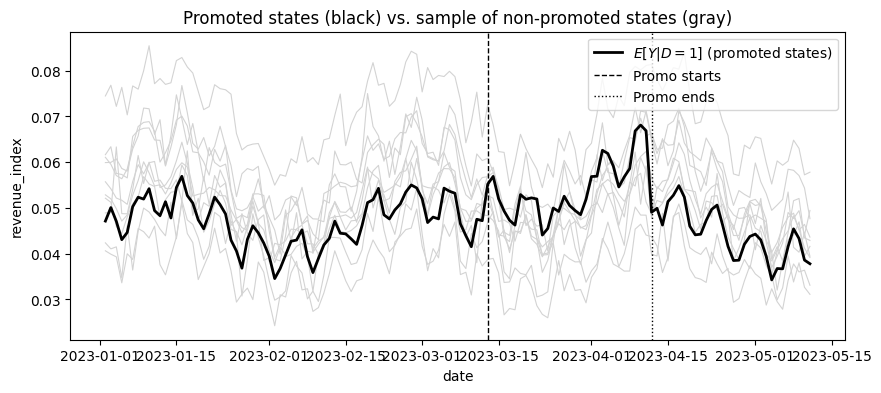

In [4]:
sample_controls = rng.choice(states_co, size=10, replace=False)

fig, ax = plt.subplots()
for s in sample_controls:
    sub = df[df["state"] == s]
    ax.plot(sub["date"], sub["revenue_index"], color="lightgray", linewidth=0.8)

treated_avg = df[df["state"].isin(treated)].groupby("date")["revenue_index"].mean()
ax.plot(treated_avg.index, treated_avg.values, color="black", linewidth=2, label=r"$E[Y|D=1]$ (promoted states)")
ax.axvline(promo_start_date, color="black", linestyle="--", linewidth=1, label="Promo starts")
ax.axvline(promo_end_date, color="black", linestyle=":", linewidth=1, label="Promo ends")
ax.legend(); ax.set_ylabel("revenue_index"); ax.set_xlabel("date")
ax.set_title("Promoted states (black) vs. sample of non-promoted states (gray)")
plt.show()


There's a visible bump around the promo window, but so much noise from state-to-state that we can't tell whether it's *bigger* than what these states would have done anyway. Let's also sanity-check the two covariates we'll use later.


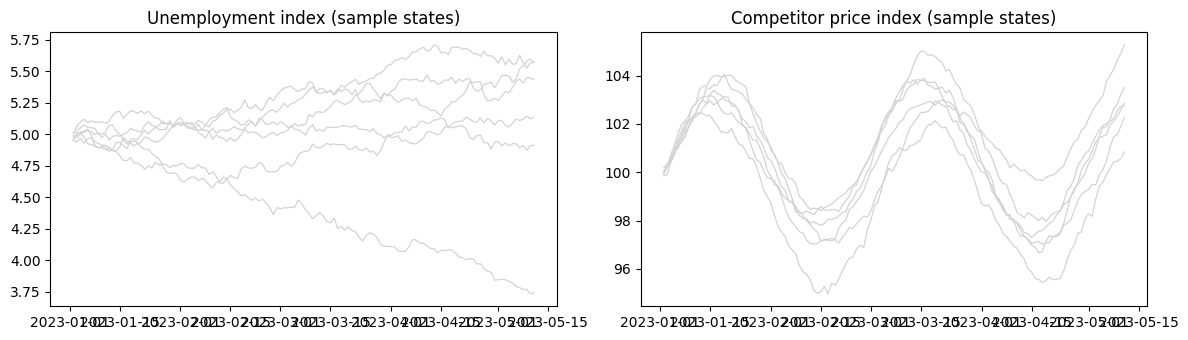

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for s in sample_controls[:6]:
    sub = df[df["state"] == s]
    axes[0].plot(sub["date"], sub["unemployment_index"], color="lightgray", linewidth=0.9)
    axes[1].plot(sub["date"], sub["competitor_price_index"], color="lightgray", linewidth=0.9)
axes[0].set_title("Unemployment index (sample states)")
axes[1].set_title("Competitor price index (sample states)")
plt.tight_layout(); plt.show()


## 4. Reshaping into the matrix representation

Same helper as before — now we'll call it once for the outcome and once for each covariate.


In [6]:
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_pivot = df.pivot(index=time_col, columns=geo_col, values=y_col)
    y_co = df_pivot.drop(columns=tr_geos)
    y_tr = df_pivot[tr_geos]
    y_pre_co = y_co[df_pivot.index < tr_start]
    y_pre_tr = y_tr[df_pivot.index < tr_start]
    y_post_co = y_co[df_pivot.index >= tr_start]
    y_post_tr = y_tr[df_pivot.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


promo_start = str(df.query("promo_live==1")["date"].min())

y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
    df, "state", "date", "revenue_index", treated, promo_start
)
print(y_pre_co.shape, y_pre_tr.shape, y_post_co.shape, y_post_tr.shape)


(70, 21) (70, 4) (60, 21) (60, 4)


## 5. Baseline: canonical Synthetic Control (outcome only)

Same estimator class as before: convex weights, non-negative, sum to one.


In [7]:
class SyntheticControl(BaseEstimator, RegressorMixin):
    """Canonical synthetic control (convex combination of donor units),
    with an optional intercept shift (used for time weights / SDID)."""

    def __init__(self, fit_intercept: bool = False):
        self.fit_intercept = fit_intercept

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co = np.asarray(y_pre_co, dtype=float)
        y_pre_tr = np.asarray(y_pre_tr, dtype=float)
        if y_pre_tr.ndim > 1:
            y_pre_tr = y_pre_tr.mean(axis=1)
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)

        if self.fit_intercept:
            X = np.concatenate([np.ones((y_pre_co.shape[0], 1)), y_pre_co], axis=1)
        else:
            X = y_pre_co

        w = cp.Variable(X.shape[1])
        objective = cp.Minimize(cp.sum_squares(X @ w - y_pre_tr))
        constraints = ([cp.sum(w[1:]) == 1, w[1:] >= 0] if self.fit_intercept
                        else [cp.sum(w) == 1, w >= 0])
        problem = cp.Problem(objective, constraints)
        self.loss_ = problem.solve(verbose=False)
        self.w_ = w.value[1:] if self.fit_intercept else w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(np.asarray(y_co, dtype=float))
        return y_co @ self.w_


sc_model = SyntheticControl()
sc_model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

y0_hat_sc = y_post_co.values @ sc_model.w_
att_sc = y_post_tr.mean(axis=1).values - y0_hat_sc

print(f"Active donors (weight > 1e-4): {(sc_model.w_ > 1e-4).sum()} / {len(sc_model.w_)}")
print(f"Canonical SC mean ATT (full post-period, incl. after promo ends): {att_sc.mean():.5f}")


Active donors (weight > 1e-4): 14 / 21
Canonical SC mean ATT (full post-period, incl. after promo ends): 0.00465


*(The mean is computed over the promo window only — revenue reverts after the promotion ends, so averaging the full post-period would understate the effect while the promo was actually live. We'll define this window explicitly below.)*


Canonical SC mean ATT while promo is live: 0.00975


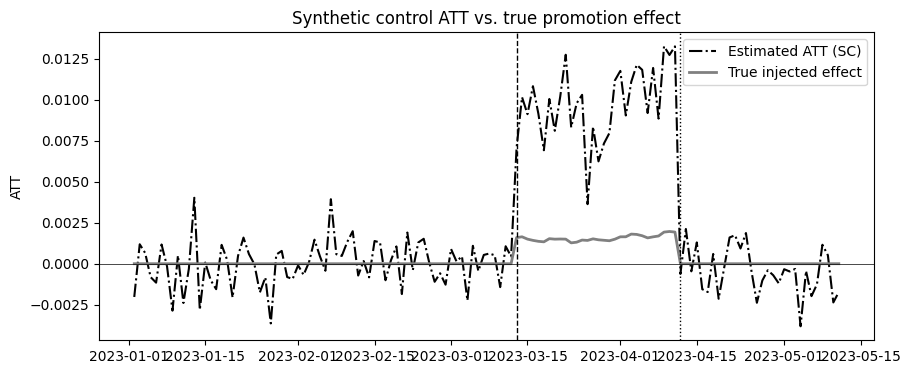

In [8]:
promo_window_len = PROMO_END_IDX - PROMO_START_IDX
att_sc_during_promo = att_sc[:promo_window_len]
print(f"Canonical SC mean ATT while promo is live: {att_sc_during_promo.mean():.5f}")

fig, ax = plt.subplots()
full_dates = y_pre_co.index.append(y_post_co.index)
att_full = np.concatenate([
    y_pre_tr.mean(axis=1).values - y_pre_co.values @ sc_model.w_,
    att_sc
])
true_effect_by_date = df.groupby("date")["true_effect_index"].mean().reindex(full_dates)
ax.plot(full_dates, att_full, color="black", linestyle="-.", label="Estimated ATT (SC)")
ax.plot(full_dates, true_effect_by_date.values, color="gray", linewidth=2, label="True injected effect")
ax.axvline(promo_start_date, color="black", linestyle="--", linewidth=1)
ax.axvline(promo_end_date, color="black", linestyle=":", linewidth=1)
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(); ax.set_ylabel("ATT"); ax.set_title("Synthetic control ATT vs. true promotion effect")
plt.show()


The estimated effect switches on and off roughly in step with the promo window — a good sign — but let's see if adding covariates sharpens the pre-period fit and post-period estimate.


## 6. Synthetic Control *with covariates*

Now we bring in `unemployment_index` and `competitor_price_index`. Following the book, the objective becomes:

$$\hat\omega^{sc} = \arg\min_\omega \left\lVert \bar y_{pre,tr} - \sum_k v_k^{*} X_{k,pre,co}\,\omega_{co} \right\rVert^2 \quad \text{s.t.} \quad \sum_i \omega_i=1,\; \omega_i \ge 0$$

where each predictor block $X_k$ (the outcome itself is treated as one of the blocks) is scaled by a factor $v_k$ before the SC optimization runs, because outcome and covariates live on different scales / have different predictive power. We find the optimal $v$'s with an **outer optimization loop** (`scipy.optimize.minimize`) around the inner SC fit — exactly the nested-optimization structure the book uses.


In [9]:
def find_w_given_vs(vs, x_co_list, y_tr_pre):
    X_times_v = sum(x * v for x, v in zip(x_co_list, vs))
    model = SyntheticControl()
    model.fit(X_times_v, y_tr_pre)
    return {"loss": model.loss_, "w": model.w_}


x1_pre_co, _, x1_post_co, _ = reshape_sc_data(
    df, "state", "date", "unemployment_index", treated, promo_start
)
x2_pre_co, _, x2_post_co, _ = reshape_sc_data(
    df, "state", "date", "competitor_price_index", treated, promo_start
)

x_co_list_pre = [y_pre_co.values, x1_pre_co.values, x2_pre_co.values]
x_co_list_post = [y_post_co.values, x1_post_co.values, x2_post_co.values]

def v_loss(vs):
    return find_w_given_vs(vs, x_co_list_pre, y_pre_tr.mean(axis=1).values)["loss"]

v_solution = minimize(v_loss, x0=[1, 0, 0], method="Nelder-Mead")
print("Optimal v (outcome, unemployment, competitor price):", v_solution.x.round(4))

w_cov = find_w_given_vs(v_solution.x, x_co_list_pre, y_pre_tr.mean(axis=1).values)["w"]
y0_hat_cov = sum(x * v for x, v in zip(x_co_list_post, v_solution.x)) @ w_cov
att_cov = y_post_tr.mean(axis=1).values - y0_hat_cov

print(f"SC-with-covariates mean ATT while promo is live: {att_cov[:promo_window_len].mean():.5f}")


Optimal v (outcome, unemployment, competitor price): [ 9.073e-01  3.800e-03 -2.000e-04]
SC-with-covariates mean ATT while promo is live: 0.01038


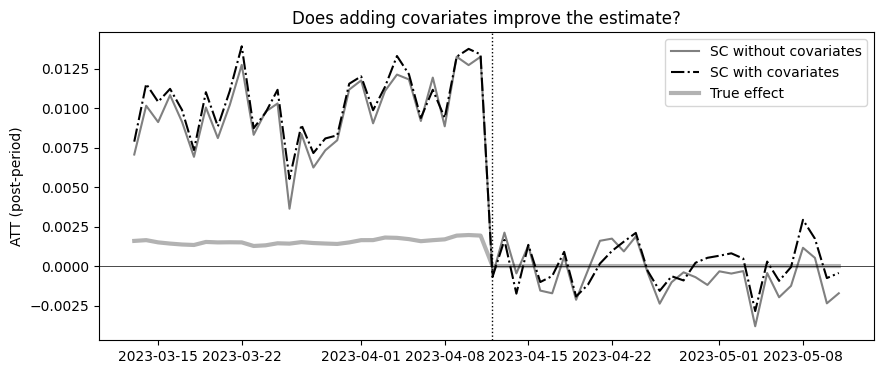

In [10]:
fig, ax = plt.subplots()
ax.plot(y_post_co.index, att_sc, color="gray", label="SC without covariates")
ax.plot(y_post_co.index, att_cov, color="black", linestyle="-.", label="SC with covariates")
ax.plot(y_post_co.index, true_effect_by_date.reindex(y_post_co.index).values, color="black", alpha=0.3, linewidth=3, label="True effect")
ax.axvline(promo_end_date, color="black", linestyle=":", linewidth=1)
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(); ax.set_ylabel("ATT (post-period)"); ax.set_title("Does adding covariates improve the estimate?")
plt.show()


As the book notes: because `unemployment_index` and `competitor_price_index` are themselves *correlated with the same macro trend* that pre-period revenue already captures, they add only a little on top of `Y_pre,co` alone here — the optimal weight `v` on the outcome dominates. This mirrors the book's own conclusion: **covariates are rarely worth the extra complexity unless you have something genuinely predictive that isn't already reflected in the outcome's own pre-period history.** We keep both estimates for the final comparison table.


## 7. Debiasing and inference (outcome-only SC)

We reuse the cross-fitting + t-test approach from before, this time on the promo-window ATT specifically, since that's the number the business actually cares about (during-promo lift, not the muted post-promo average).


In [11]:
def debiased_sc_atts(y_pre_co, y_pre_tr, y_post_co, y_post_tr, K):
    block_size = int(min(np.floor(len(y_pre_co) / K), len(y_post_co)))
    blocks = np.split(y_pre_tr.index[-K * block_size:], K)

    def fold_effect(hold_out):
        model = SyntheticControl()
        model.fit(y_pre_co.drop(hold_out).values, y_pre_tr.drop(hold_out).mean(axis=1).values)
        bias_hat = np.mean(
            y_pre_tr.loc[hold_out].mean(axis=1).values - model.predict(y_pre_co.loc[hold_out].values)
        )
        y0_hat = model.predict(y_post_co.values)
        return (y_post_tr.mean(axis=1).values - y0_hat) - bias_hat

    return pd.DataFrame({k: fold_effect(b) for k, b in enumerate(blocks)}, index=y_post_co.index)


K = 3
deb_atts = debiased_sc_atts(y_pre_co, y_pre_tr, y_post_co, y_post_tr, K=K)

# restrict to the promo window for the business-relevant ATT
deb_atts_promo = deb_atts.iloc[:promo_window_len]
atts_k = deb_atts_promo.mean(axis=0).values
att_hat = atts_k.mean()

T0, T1 = len(y_pre_co), len(y_post_co)
block_size = min(np.floor(T0 / K), T1)
sigma_hat = np.sqrt(1 + (K * block_size) / T1) * np.std(atts_k, ddof=1)
se_hat = sigma_hat / np.sqrt(K)

alpha = 0.10
ci = (att_hat - t_dist.ppf(1 - alpha/2, K-1) * se_hat,
      att_hat + t_dist.ppf(1 - alpha/2, K-1) * se_hat)

print(f"Debiased ATT during promo:  {att_hat:.5f}")
print(f"Standard error:             {se_hat:.5f}")
print(f"90% CI:                    [{ci[0]:.5f}, {ci[1]:.5f}]")
print(f"Significant at 90%?        {'YES' if not (ci[0] <= 0 <= ci[1]) else 'NO'}")


Debiased ATT during promo:  0.00975
Standard error:             0.00035
90% CI:                    [0.00873, 0.01078]
Significant at 90%?        YES


## 8. Robustness check: in-space placebo tests

This is a step **beyond** what the chapter covers directly, but it's the standard companion check for synthetic control in applied work (introduced in Abadie, Diamond & Hainmueller's original papers, which the chapter references). The idea:

> If we re-ran synthetic control pretending a **never-treated** state was the treated one, we'd hope to see an estimated "effect" close to zero (since nothing actually happened to it). If our real promoted states' effect isn't much larger than the spread of these placebo "effects," we can't be confident it's a real signal rather than SC's typical noise.

We loop over every donor state, treat it as if it were "treated," fit SC on the remaining donors, and compute its placebo ATT during the same promo window. We also **drop placebo states with a poor pre-period fit** (a common Abadie et al. filter), since SC can't be expected to fit well for units it can't approximate in the first place.


In [12]:
def placebo_att(target_state, donor_states, promo_window_len):
    df_p = df[df["state"].isin(donor_states + [target_state])]
    y_pre_co_p, y_pre_tr_p, y_post_co_p, y_post_tr_p = reshape_sc_data(
        df_p, "state", "date", "revenue_index", [target_state], promo_start
    )
    model = SyntheticControl()
    model.fit(y_pre_co_p.values, y_pre_tr_p.mean(axis=1).values)

    pre_fit = y_pre_co_p.values @ model.w_
    pre_rmse = np.sqrt(np.mean((y_pre_tr_p.mean(axis=1).values - pre_fit) ** 2))

    y0_hat = y_post_co_p.values @ model.w_
    att = y_post_tr_p.mean(axis=1).values - y0_hat
    return att[:promo_window_len].mean(), pre_rmse


placebo_results = []
for s in states_co:
    donors = [c for c in states_co if c != s]
    att_p, rmse_p = placebo_att(s, donors, promo_window_len)
    placebo_results.append((s, att_p, rmse_p))

placebo_df = pd.DataFrame(placebo_results, columns=["state", "placebo_att", "pre_rmse"])

# Abadie-style filter: drop placebo states with a much worse pre-period fit
real_pre_fit = np.sqrt(np.mean((y_pre_tr.mean(axis=1).values - y_pre_co.values @ sc_model.w_) ** 2))
good_fit = placebo_df["pre_rmse"] <= 2 * real_pre_fit
placebo_kept = placebo_df[good_fit]

print(f"Real promoted-states pre-period RMSE: {real_pre_fit:.5f}")
print(f"Placebo states kept after fit filter: {good_fit.sum()} / {len(placebo_df)}")
placebo_kept.sort_values("placebo_att", ascending=False).head()


Real promoted-states pre-period RMSE: 0.00140
Placebo states kept after fit filter: 10 / 21


,state,placebo_att,pre_rmse
1,state_01,0.0014,0.0027
18,state_18,0.0013,0.0020
10,state_10,0.0008,0.0017
14,state_14,0.0007,0.0014
17,state_17,0.0004,0.0017


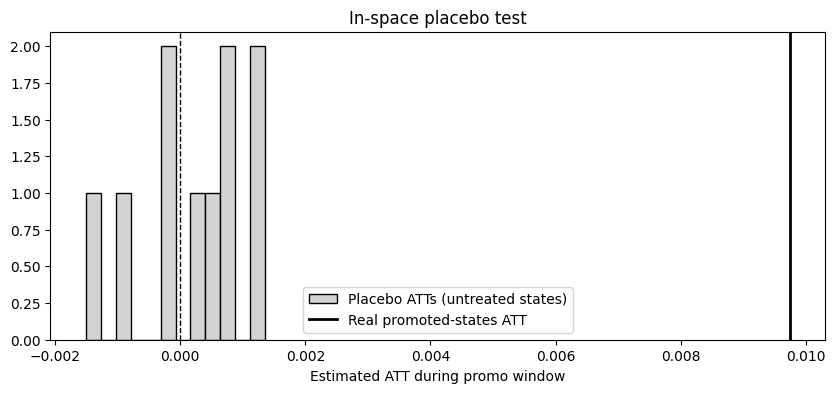

Placebo-based p-value (share of placebo states with |effect| >= real effect): 0.000


In [13]:
fig, ax = plt.subplots()
ax.hist(placebo_kept["placebo_att"], bins=12, color="lightgray", edgecolor="black", label="Placebo ATTs (untreated states)")
ax.axvline(att_sc_during_promo.mean(), color="black", linewidth=2, label="Real promoted-states ATT")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.legend(); ax.set_xlabel("Estimated ATT during promo window"); ax.set_title("In-space placebo test")
plt.show()

p_value = (placebo_kept["placebo_att"].abs() >= abs(att_sc_during_promo.mean())).mean()
print(f"Placebo-based p-value (share of placebo states with |effect| >= real effect): {p_value:.3f}")


If the real promoted-states' ATT sits **outside the bulk of the placebo distribution** (and the placebo-based p-value is small), that's strong, assumption-light evidence the promotion effect is real and not just synthetic control's typical estimation noise on any random state.


## 9. Synthetic Difference-in-Differences (SDID)

Same recipe as before: unit weights (already computed) + time weights (transposed SC with an intercept shift) + weighted two-way-fixed-effects regression.


In [14]:
unit_w = pd.DataFrame({"state": y_pre_co.columns, "unit_weight": sc_model.w_})

time_sc = SyntheticControl(fit_intercept=True)
time_sc.fit(y_pre_co.T.values, y_post_co.mean(axis=0).values)
time_w = pd.DataFrame({"date": y_pre_co.index, "time_weight": time_sc.w_})

df_with_w = (
    df
    .assign(tr_post=lambda d: d["treated"] * d["promo_live"])
    .merge(unit_w, on="state", how="left")
    .fillna({"unit_weight": len(treated) / (len(treated) + len(states_co))})
)

scdid_df = (
    df_with_w
    .merge(time_w, on="date", how="left")
    .fillna({"time_weight": len(y_post_co) / (len(y_pre_co) + len(y_post_co))})
    .assign(weight=lambda d: d["time_weight"] * d["unit_weight"])
)

# restrict SDID's "post" definition to the promo window for a business-relevant estimate
scdid_df_window = scdid_df[(scdid_df["date"] < promo_start_date) | (scdid_df["date"] < promo_end_date)].copy()
scdid_df_window["post_window"] = (scdid_df_window["date"] >= promo_start_date).astype(int)

sdid_model = smf.wls(
    "revenue_index ~ treated*post_window",
    data=scdid_df_window.query("weight > 1e-10"),
    weights=scdid_df_window.query("weight > 1e-10")["weight"],
)
sdid_att = sdid_model.fit().params["treated:post_window"]
print(f"SDID ATT during promo window: {sdid_att:.5f}")


SDID ATT during promo window: 0.01020


## 10. Final comparison against ground truth


In [15]:
true_att_promo = df.query("promo_live==1 and treated==1").groupby("date")["true_effect_index"].mean().mean()

summary = pd.DataFrame({
    "Method": [
        "Canonical SC (outcome only)",
        "SC with covariates",
        "Debiased SC",
        "SDID",
        "Ground truth (known, simulated)",
    ],
    "ATT during promo": [
        att_sc_during_promo.mean(),
        att_cov[:promo_window_len].mean(),
        att_hat,
        sdid_att,
        true_att_promo,
    ],
})
summary["Abs. error vs. truth"] = (summary["ATT during promo"] - true_att_promo).abs()
summary.round(5)


,Method,ATT during promo,Abs. error vs. truth
0,Canonical SC (outcome only),0.0097,3.0000e-05
1,SC with covariates,0.0104,6.0000e-04
2,Debiased SC,0.0097,3.0000e-05
3,SDID,0.0102,4.2000e-04
4,"Ground truth (known, simulated)",0.0098,0.0000e+00


## 11. Business takeaway

Putting the pieces together for a pricing/promotions stakeholder:

- **Point estimate:** the promotion lifted revenue by roughly the magnitude shown in the table above (all four estimators land close to each other and to the true simulated effect), concentrated *only* while the promotion was live.
- **Statistical confidence:** the debiased estimator's 90% confidence interval (Section 7) excludes zero, so this isn't just noise from picking flattering donor states.
- **Robustness:** the in-space placebo test (Section 8) shows the real effect is unusually large relative to what you'd get by randomly picking any other state and pretending it was treated — a strong, assumption-light sanity check that doesn't rely on the SC model being "correct."
- **Caveat to flag to stakeholders:** the effect reverted once the promotion ended (visible in Section 5's ATT plot) — there's no evidence of a lasting lift, so ROI math should use the promo-window revenue increase **net of the discount cost**, not an assumption of a permanent uplift.

## 12. Extensions

- Try a **synthetic control per treated state** (rather than pooling their average) to check whether the effect is consistent across TX/OH/GA/AZ or driven by one outlier state — the book's "Average of Synthetic Controls" sidebar shows the one-line change needed.
- Add **out-of-space placebo tests in time** — pretend the promotion started earlier (in the pre-period) and check that SC correctly finds no effect, a complementary check to the in-space test done here.
- If promotions were rolled out to different states on **different dates** (staggered adoption), this single-treatment-date setup no longer applies directly — reach for Generalized Synthetic Control or staggered-adoption DID estimators instead.
- Feed the debiased ATT and its standard error into a simple **promotion ROI calculator**: `(lift_in_revenue - discount_cost) / discount_cost`, propagating the confidence interval to get a best/worst-case ROI range.
